# Setting up

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mkdir -p failed for path /gpfs/home/yb2612/.config/matplotlib: [Errno 13] Permission denied: '/gpfs/home/yb2612/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-nr_wpafr because there was an issue with the default path (/gpfs/home/yb2612/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [2]:
#---------------------------------
# PLOT CONFUSION MATRIX
#---------------------------------
def plot_confusion_matrix(true_labels, pred_labels, xlabel, ylabel, title_suffix=''):
    confusion = pd.crosstab(true_labels, pred_labels)
    confusion_normalized = confusion.div(confusion.sum(axis=1), axis=0).fillna(0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_normalized, annot=True, fmt=".2f", cmap="viridis")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"Confusion Matrix {title_suffix}")
    plt.tight_layout()
    plt.show()

broad_results_dir = "/gpfs/home/yb2612/proteomics/home/yb2612/results/celesta"
detailed_results_dir = "/gpfs/home/yb2612/proteomics/home/yb2612/results/celesta/detailed_cell_types"

# Define bucket mapping
bucket_map = {
    "Cytotoxic NK": "CD8_T",
    "Exhausted CD8": "CD8_T",
    "Treg": "CD4_T",
    "Th1": "CD4_T"
}

# Broad vs. detailed cell types (bucketed)


Processing: cervical_28873_raw_arcsinh
Unknown (Broad): 0.6%, Unknown (Detailed): 0.7%


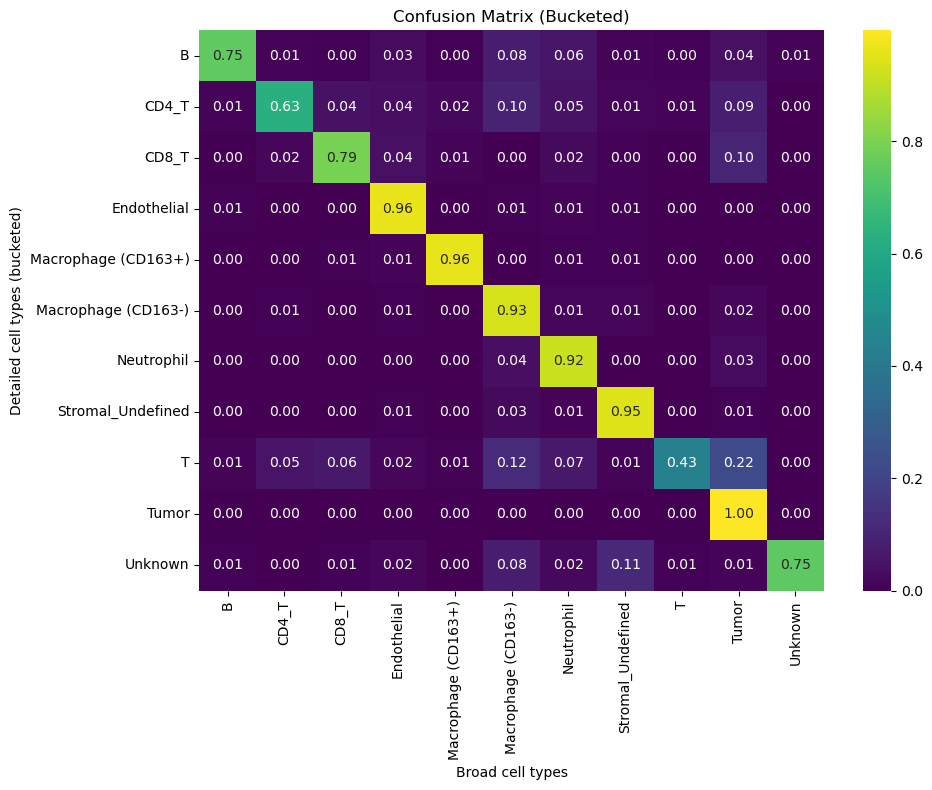


Processing: cervical_04738_raw_arcsinh
Unknown (Broad): 0.4%, Unknown (Detailed): 0.3%


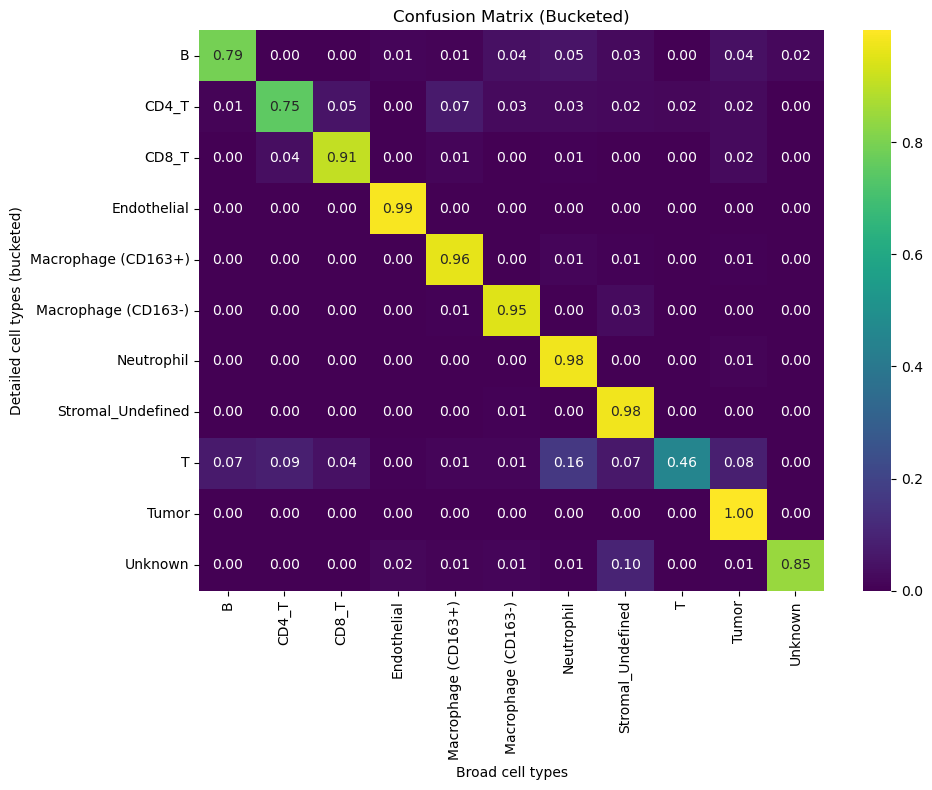


Processing: cervical_02433_raw_arcsinh
Unknown (Broad): 0.4%, Unknown (Detailed): 0.5%


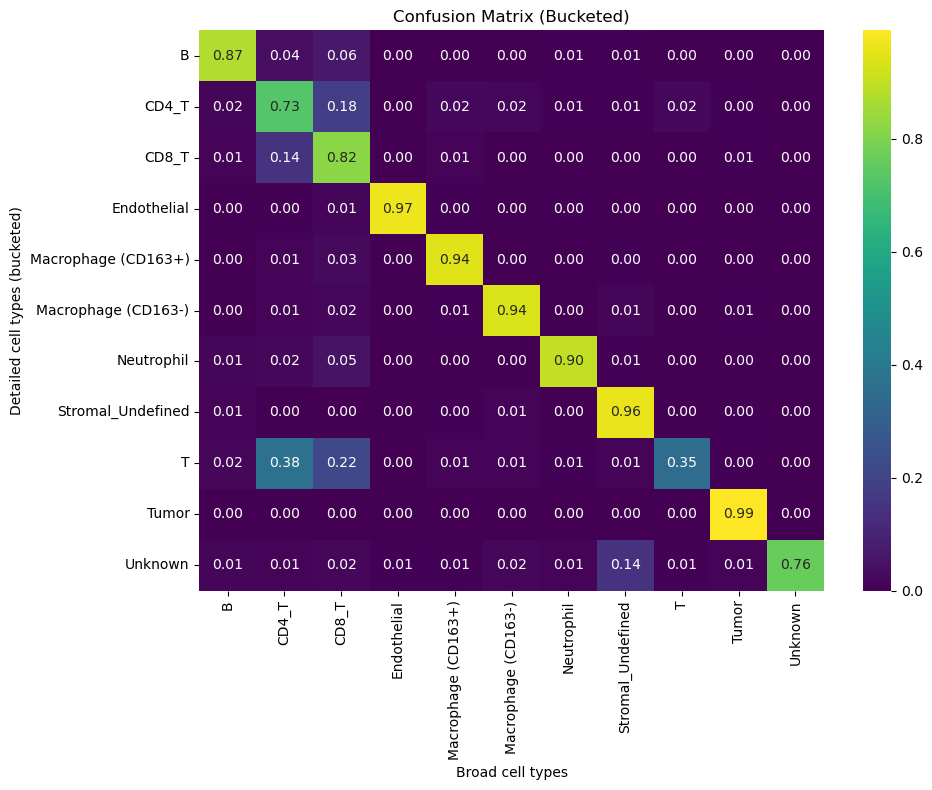


Processing: cervical_07688_raw_arcsinh
Unknown (Broad): 2.2%, Unknown (Detailed): 1.6%


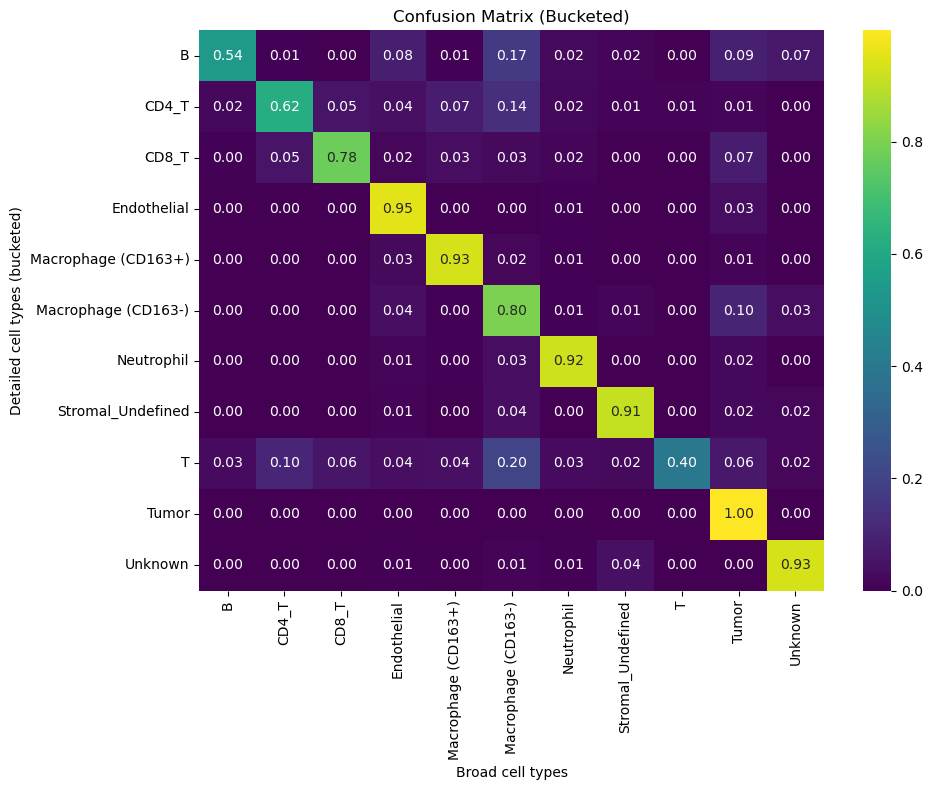


Processing: cervical_09002_raw_arcsinh
Unknown (Broad): 0.5%, Unknown (Detailed): 0.4%


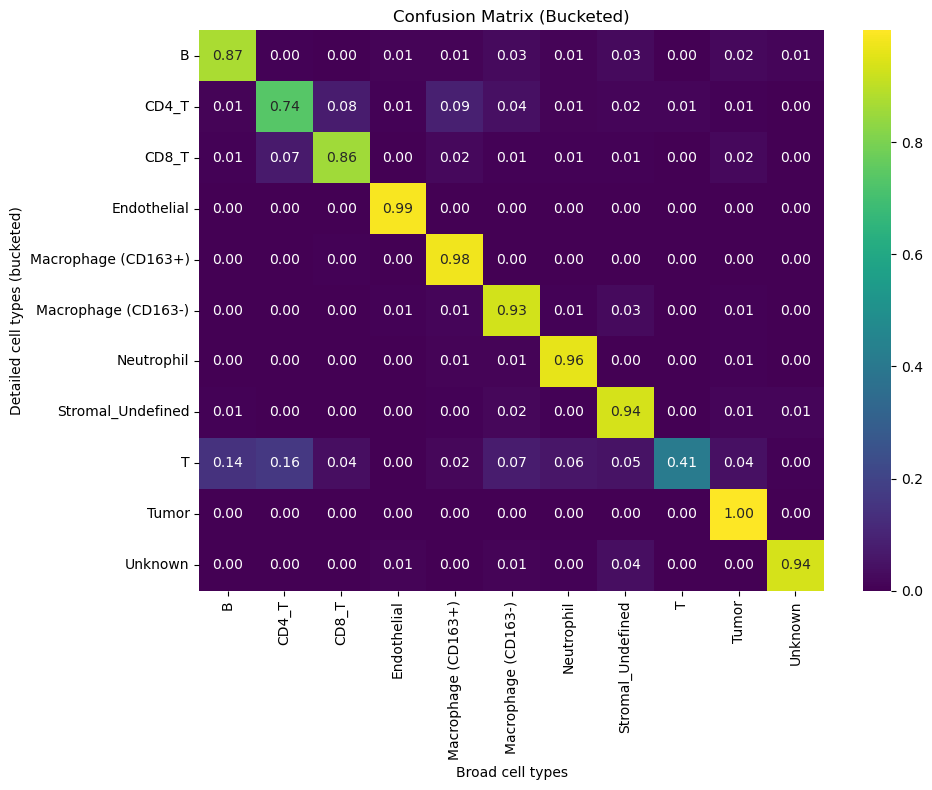


Processing: cervical_34933_raw_arcsinh
Unknown (Broad): 0.1%, Unknown (Detailed): 0.1%


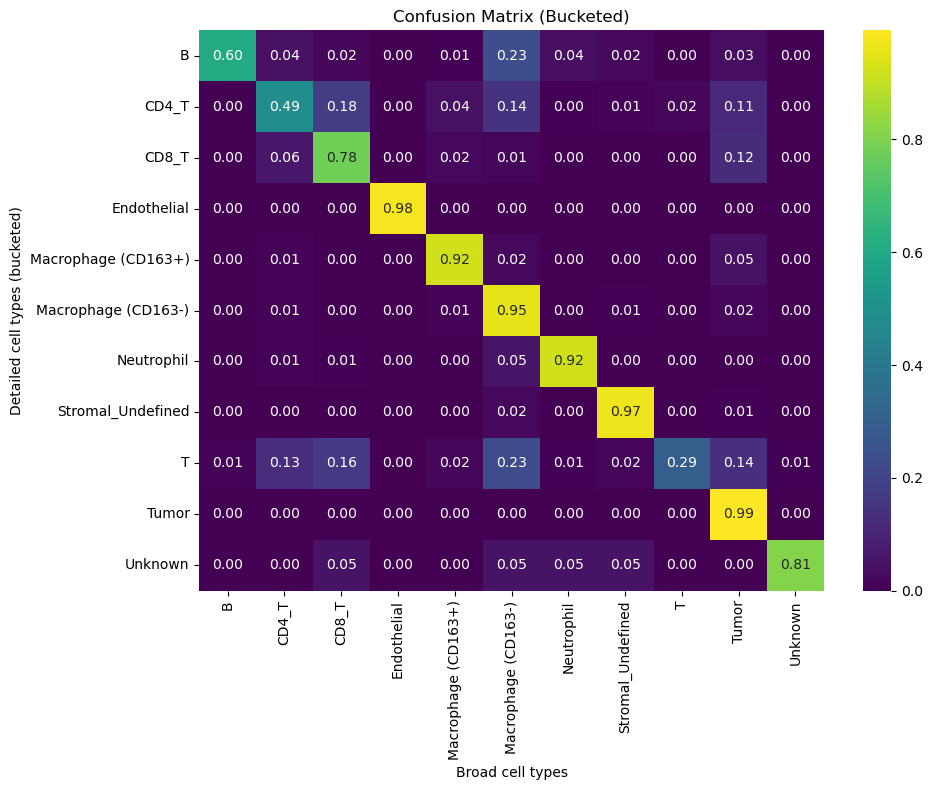


Processing: cervical_49411_raw_arcsinh
Unknown (Broad): 0.5%, Unknown (Detailed): 0.5%


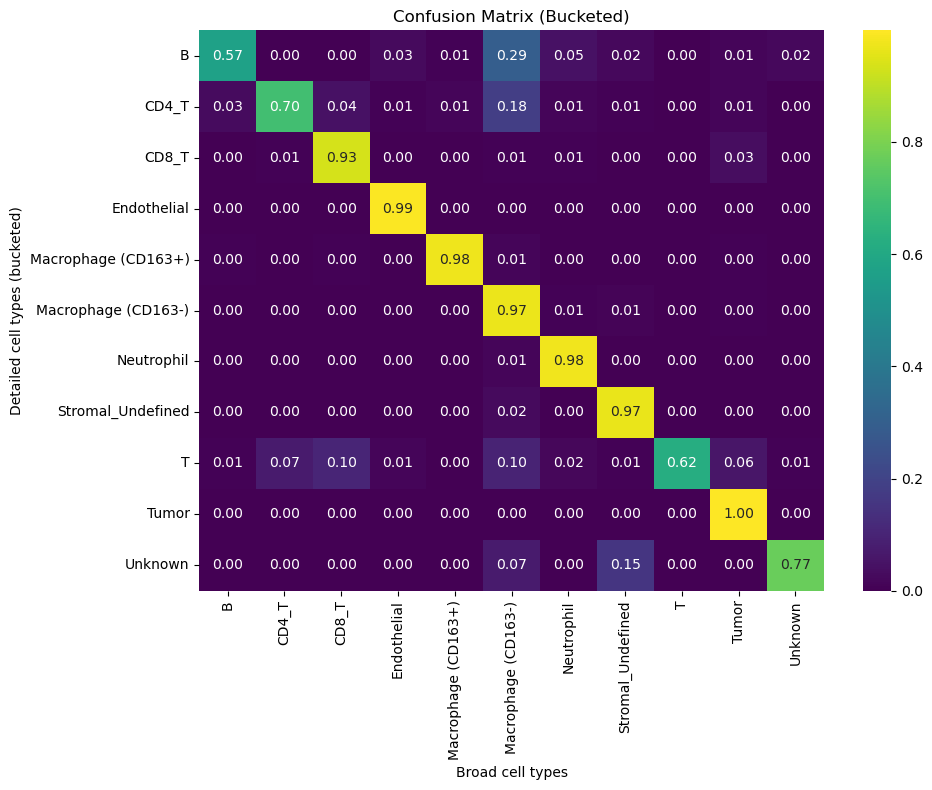


Processing: cervical_00862_raw_arcsinh
Unknown (Broad): 0.6%, Unknown (Detailed): 0.4%


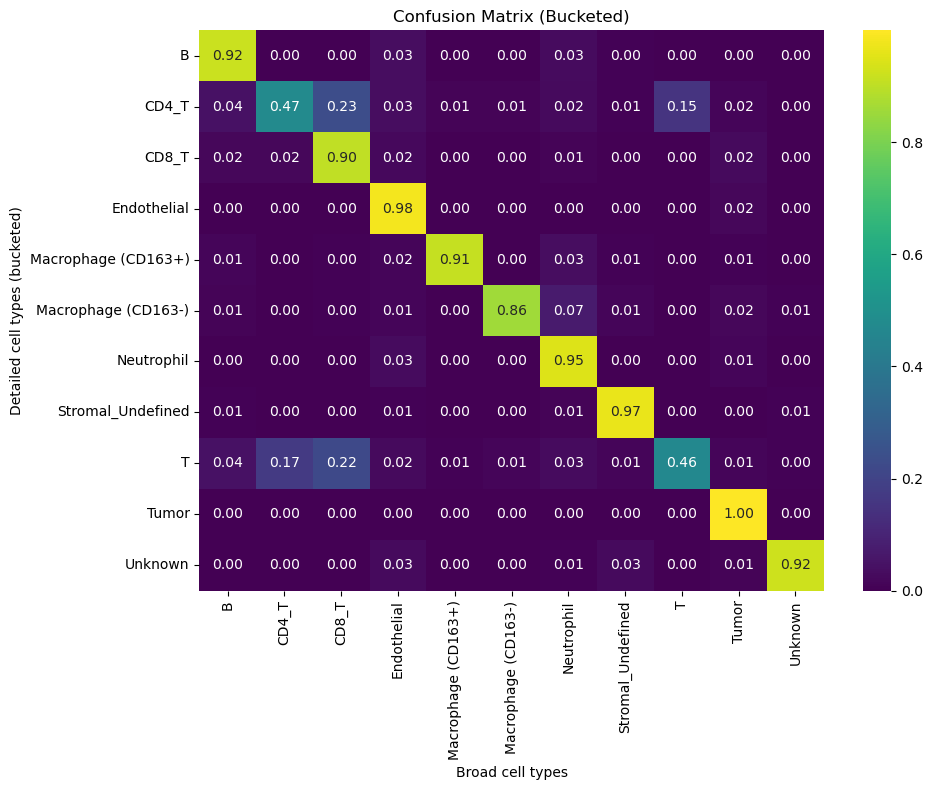


Processing: cervical_10103_raw_arcsinh
Unknown (Broad): 0.3%, Unknown (Detailed): 0.3%


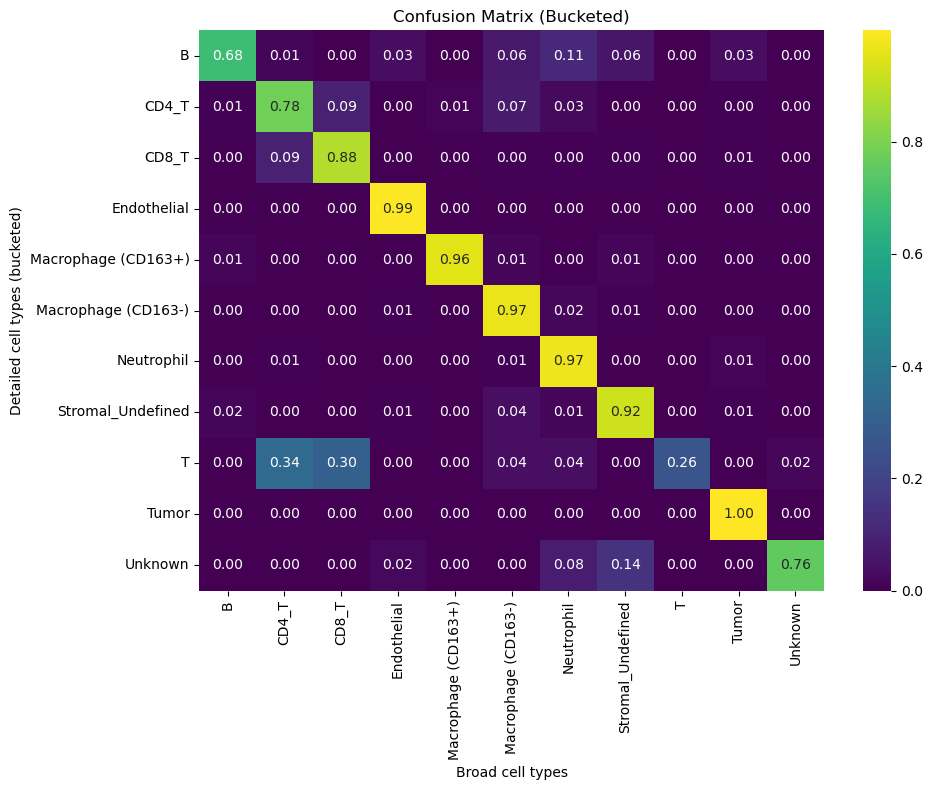


Processing: cervical_10285_raw_arcsinh
Unknown (Broad): 0.5%, Unknown (Detailed): 0.3%


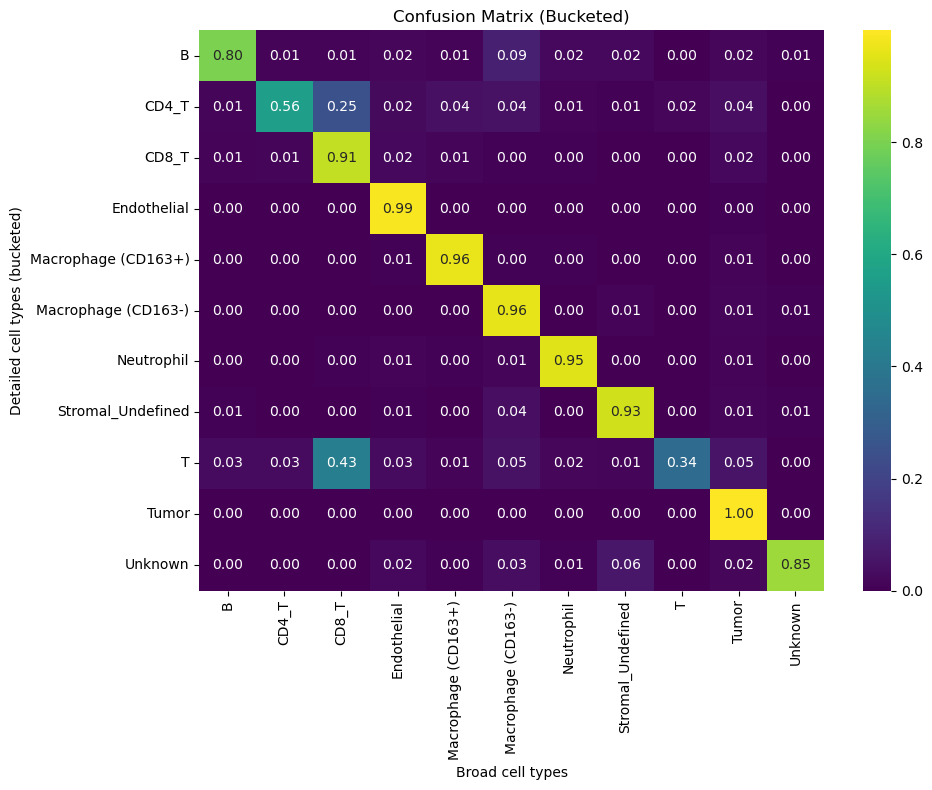


Processing: cervical_07291_raw_arcsinh
Unknown (Broad): 0.2%, Unknown (Detailed): 0.2%


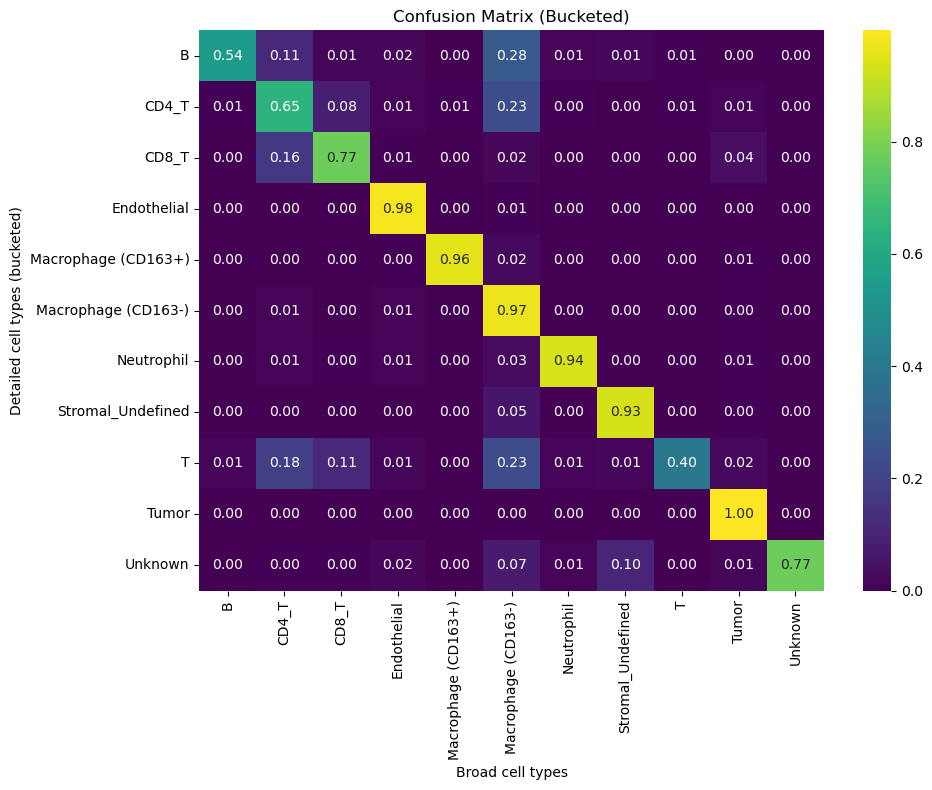


Processing: cervical_39367_raw_arcsinh
Unknown (Broad): 0.3%, Unknown (Detailed): 0.2%


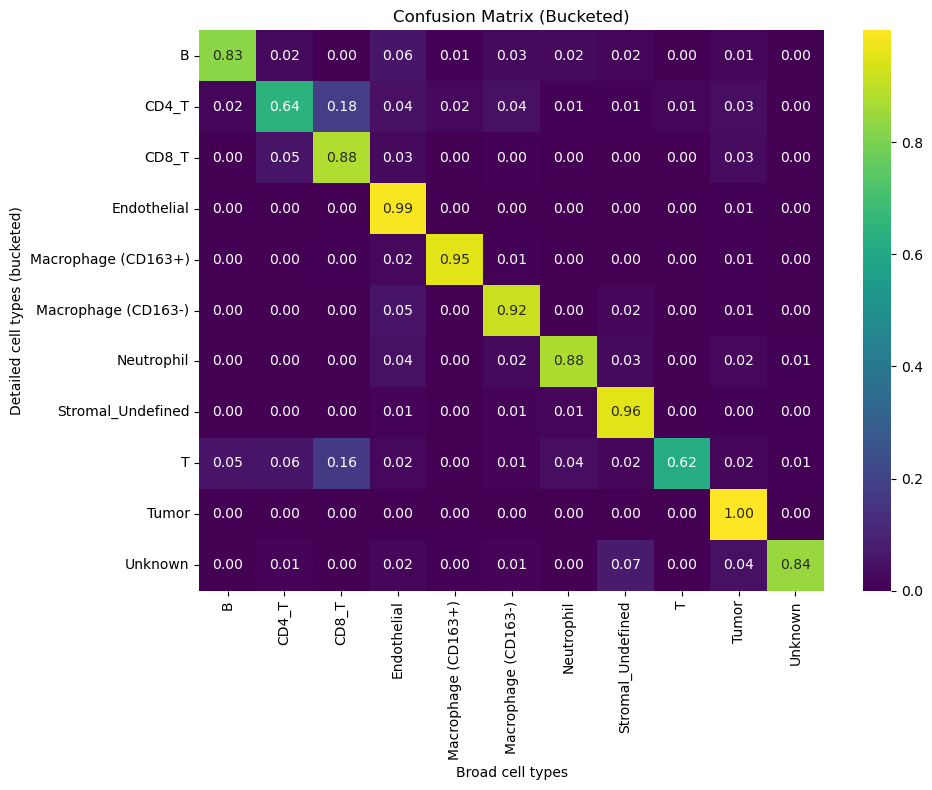


Processing: cervical_00438_raw_arcsinh
Unknown (Broad): 0.4%, Unknown (Detailed): 0.3%


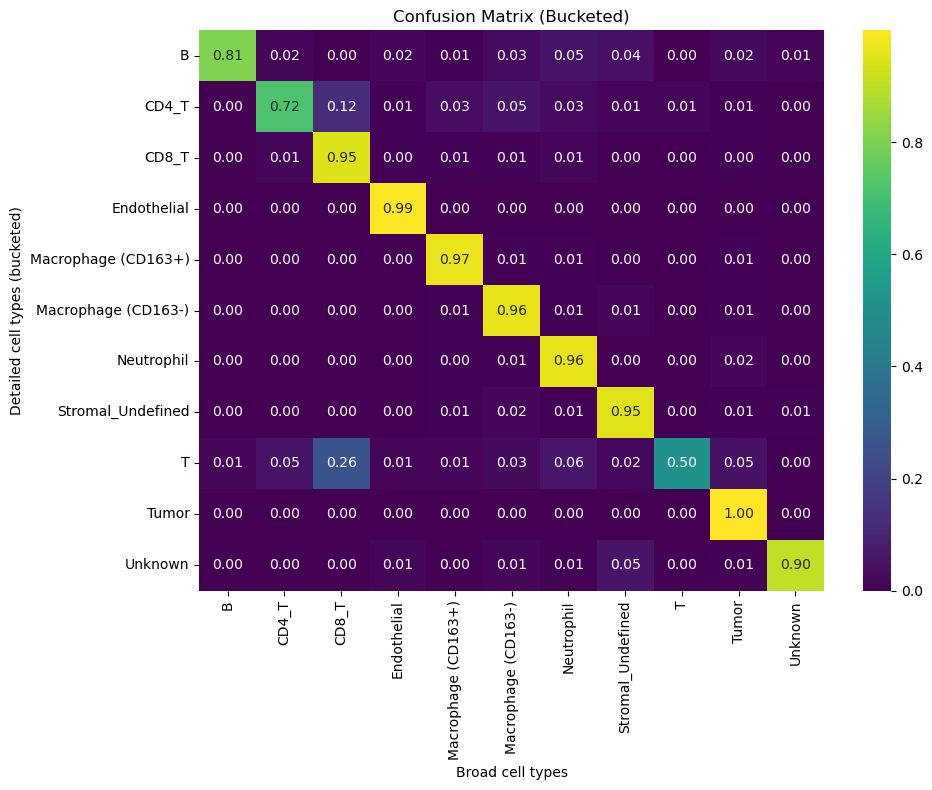


Processing: cervical_08153_raw_arcsinh
Unknown (Broad): 0.8%, Unknown (Detailed): 0.9%


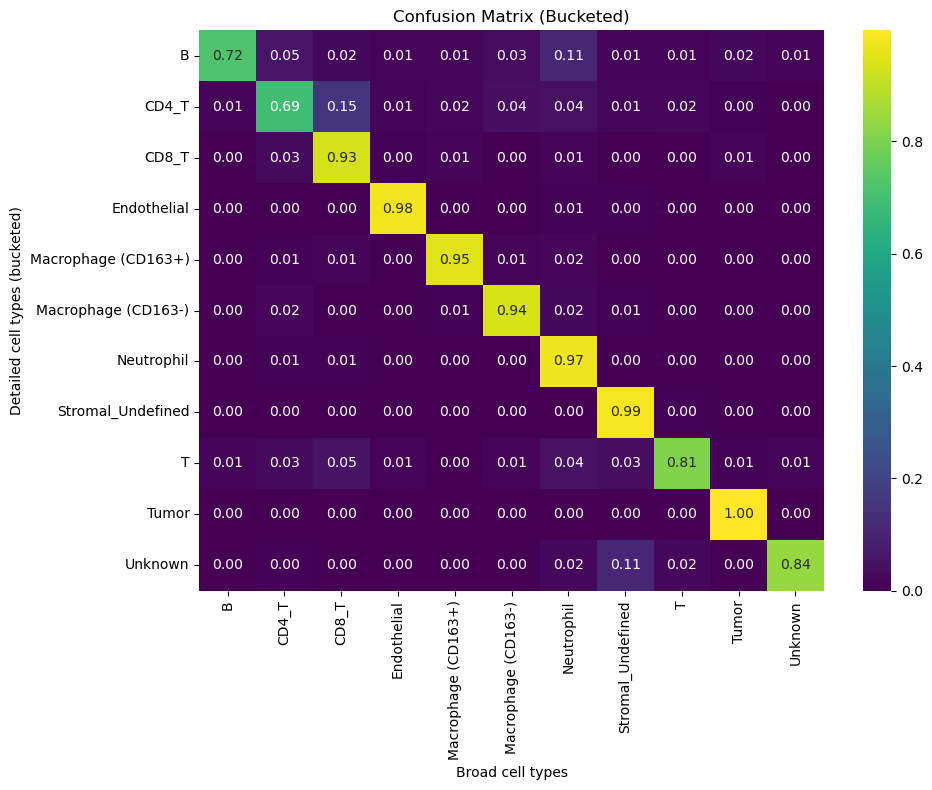


Processing: cervical_07611_raw_arcsinh
Missing file for cervical_07611_raw_arcsinh, skipping.


In [3]:
# Loop through subdirs
for subdir in os.listdir(broad_results_dir):
    if not subdir.startswith("cervical") or not os.path.isdir(os.path.join(broad_results_dir, subdir)):
        continue

    print(f"\nProcessing: {subdir}")

    # File paths
    filename = f"{subdir}_high_anchor_default_high_iter_default_final_cell_type_assignment.csv"
    broad_path = os.path.join(broad_results_dir, subdir, filename)
    detailed_path = os.path.join(detailed_results_dir, subdir, filename)

    if not (os.path.isfile(broad_path) and os.path.isfile(detailed_path)):
        print(f"Missing file for {subdir}, skipping.")
        continue

    # Read data
    broad_df = pd.read_csv(broad_path)
    detailed_df = pd.read_csv(detailed_path)

    if "Final cell type" not in broad_df.columns or "Final cell type" not in detailed_df.columns:
        print(f"'Final cell type' column missing in {subdir}, skipping.")
        continue

    broad = broad_df["Final cell type"]
    detailed = detailed_df["Final cell type"]

    # Calculate % unknown
    pct_unknown_broad = (broad == "Unknown").mean() * 100
    pct_unknown_detailed = (detailed == "Unknown").mean() * 100
    print(f"Unknown (Broad): {pct_unknown_broad:.1f}%, Unknown (Detailed): {pct_unknown_detailed:.1f}%")

    # Apply bucketing
    bucketed_detailed = detailed.replace(bucket_map)

    # Plot bucketed matrix
    plot_confusion_matrix(
        bucketed_detailed,
        broad,
        xlabel="Broad cell types",
        ylabel="Detailed cell types (bucketed)",
        title_suffix="(Bucketed)"
    )

# Broad vs. detailed cell types (raw)


Processing: cervical_28873_raw_arcsinh
Unknown (Broad): 0.6%, Unknown (Detailed): 0.7%


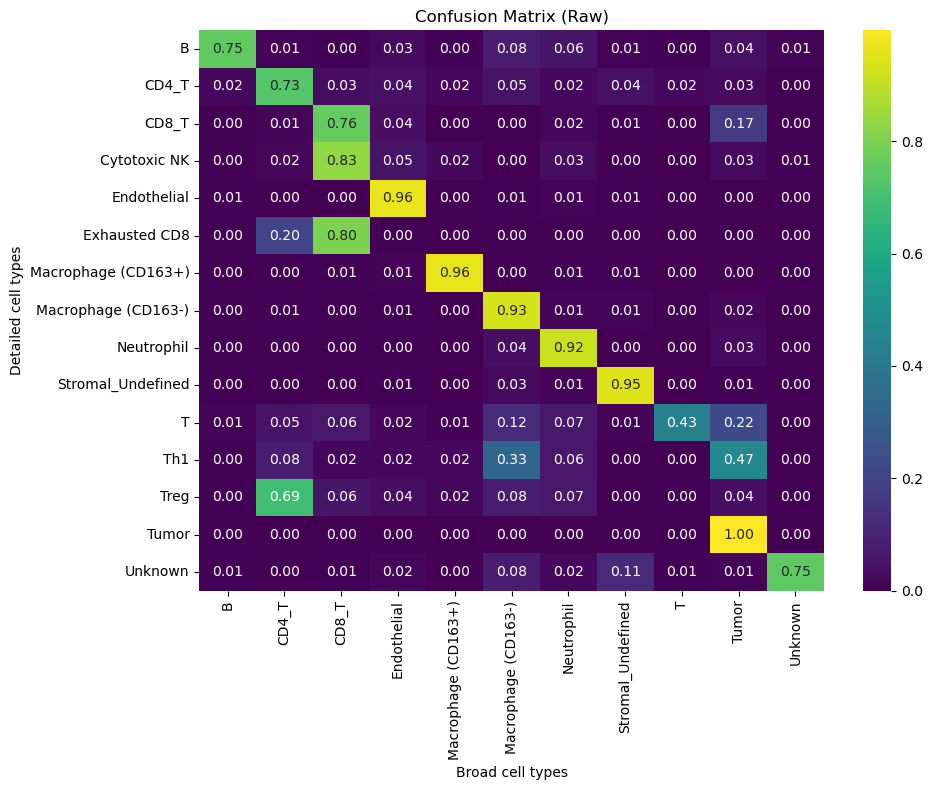


Processing: cervical_04738_raw_arcsinh
Unknown (Broad): 0.4%, Unknown (Detailed): 0.3%


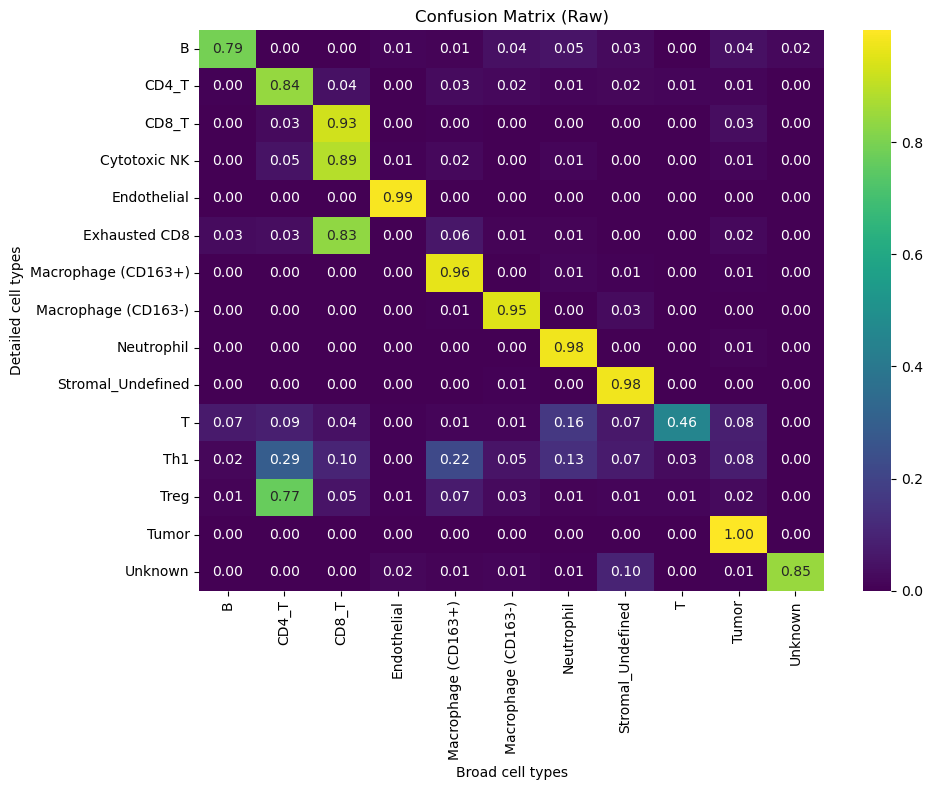


Processing: cervical_02433_raw_arcsinh
Unknown (Broad): 0.4%, Unknown (Detailed): 0.5%


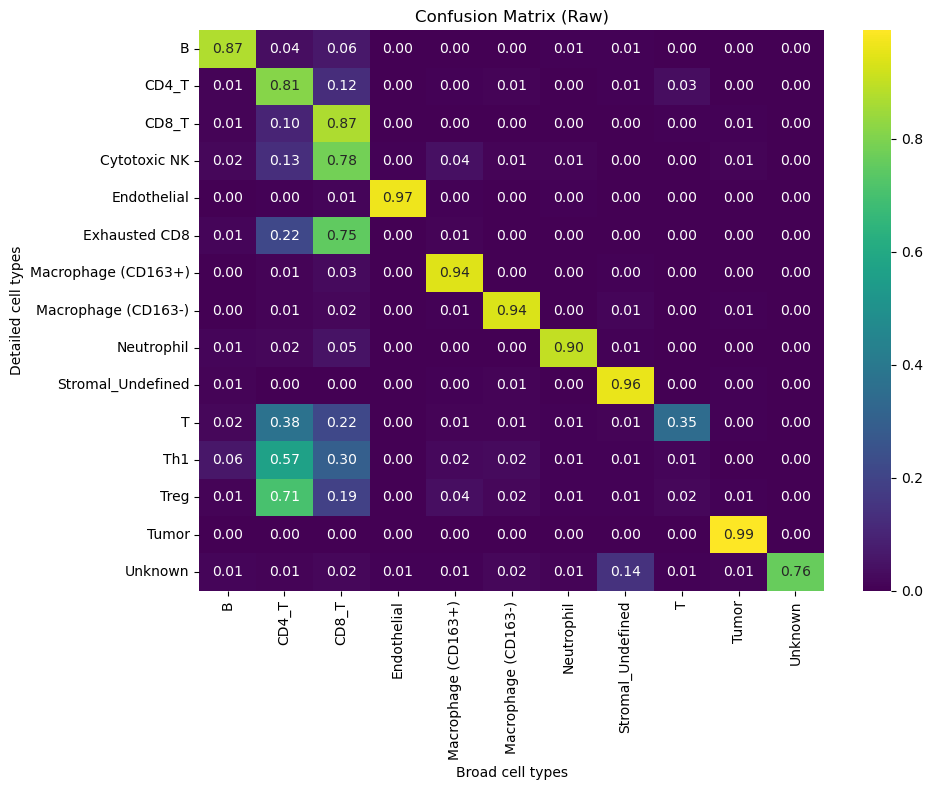


Processing: cervical_07688_raw_arcsinh
Unknown (Broad): 2.2%, Unknown (Detailed): 1.6%


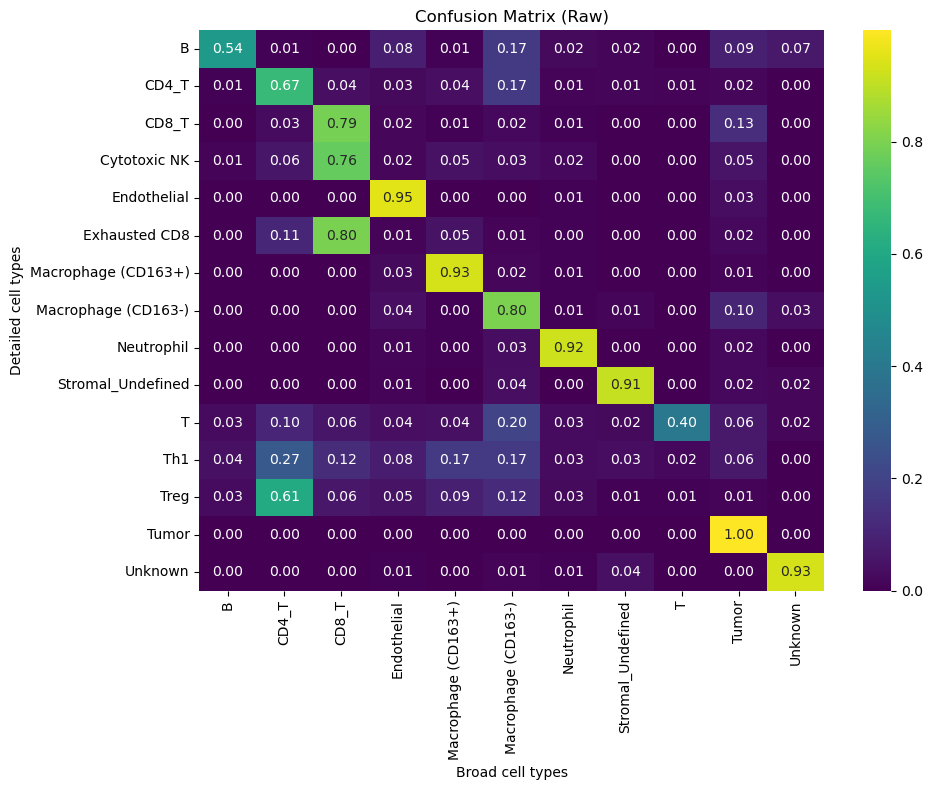


Processing: cervical_09002_raw_arcsinh
Unknown (Broad): 0.5%, Unknown (Detailed): 0.4%


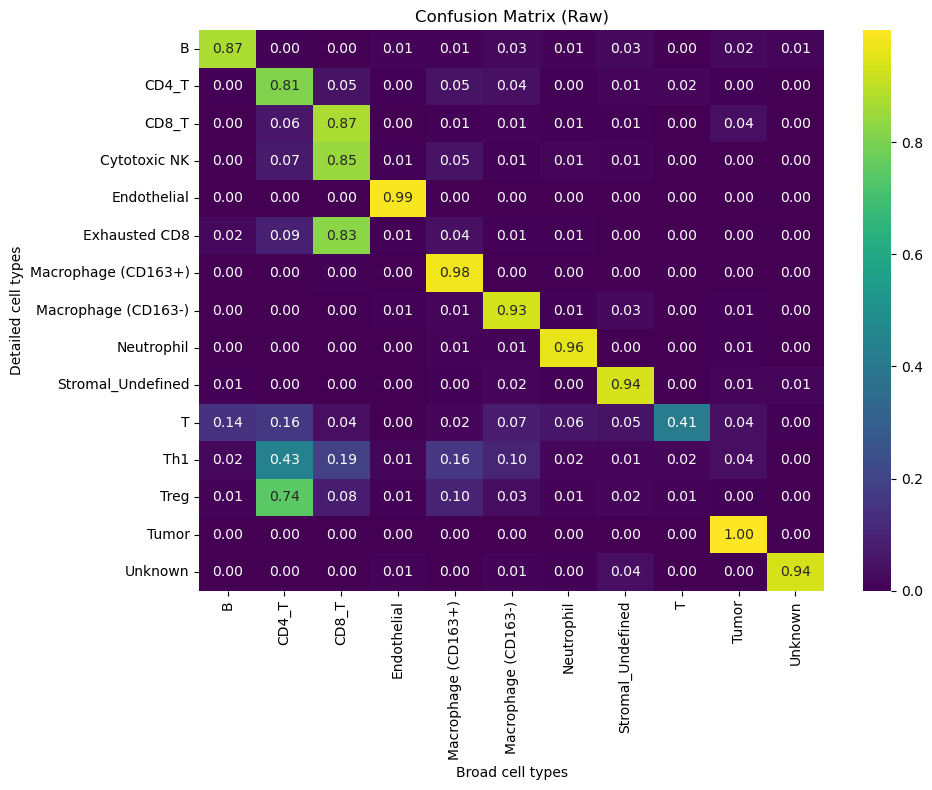


Processing: cervical_34933_raw_arcsinh
Unknown (Broad): 0.1%, Unknown (Detailed): 0.1%


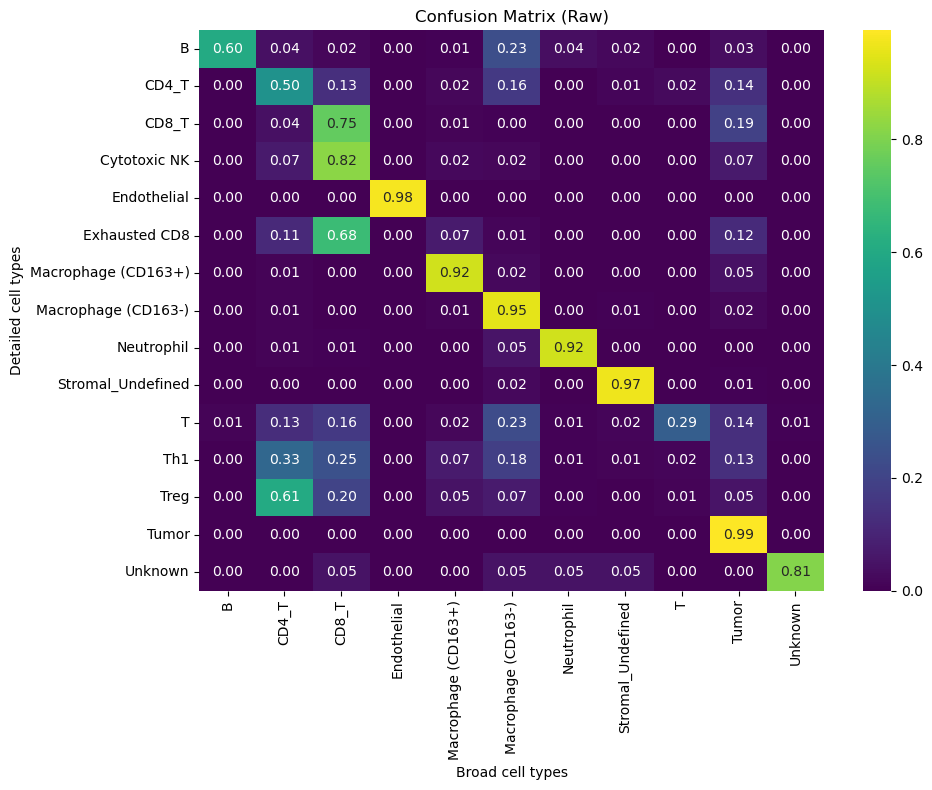


Processing: cervical_49411_raw_arcsinh
Unknown (Broad): 0.5%, Unknown (Detailed): 0.5%


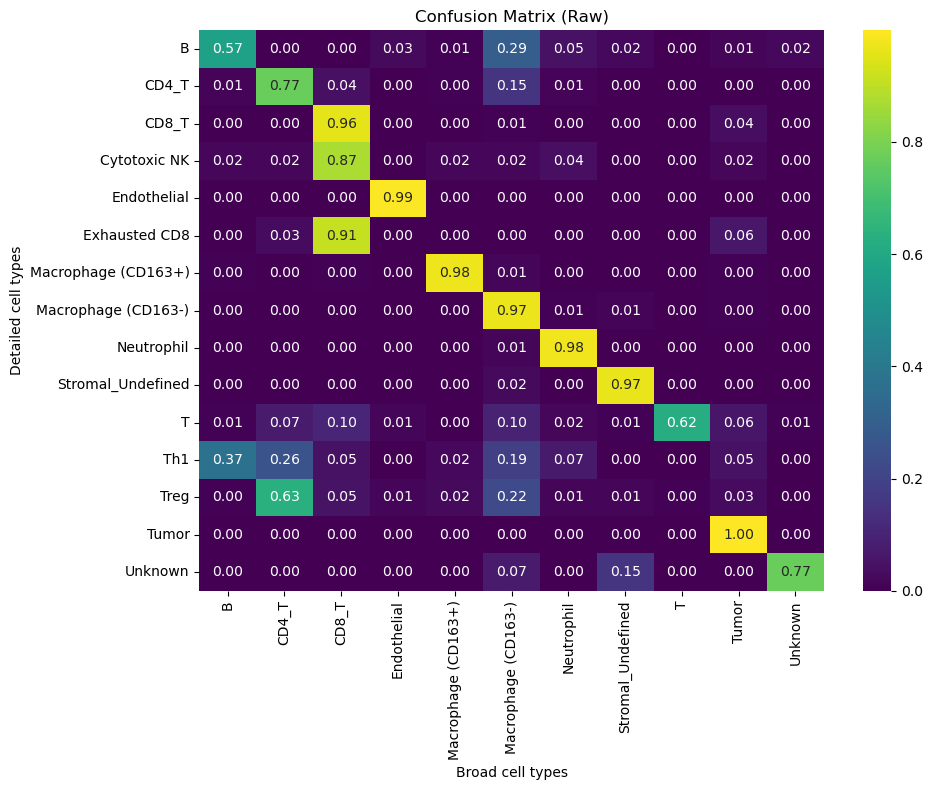


Processing: cervical_00862_raw_arcsinh
Unknown (Broad): 0.6%, Unknown (Detailed): 0.4%


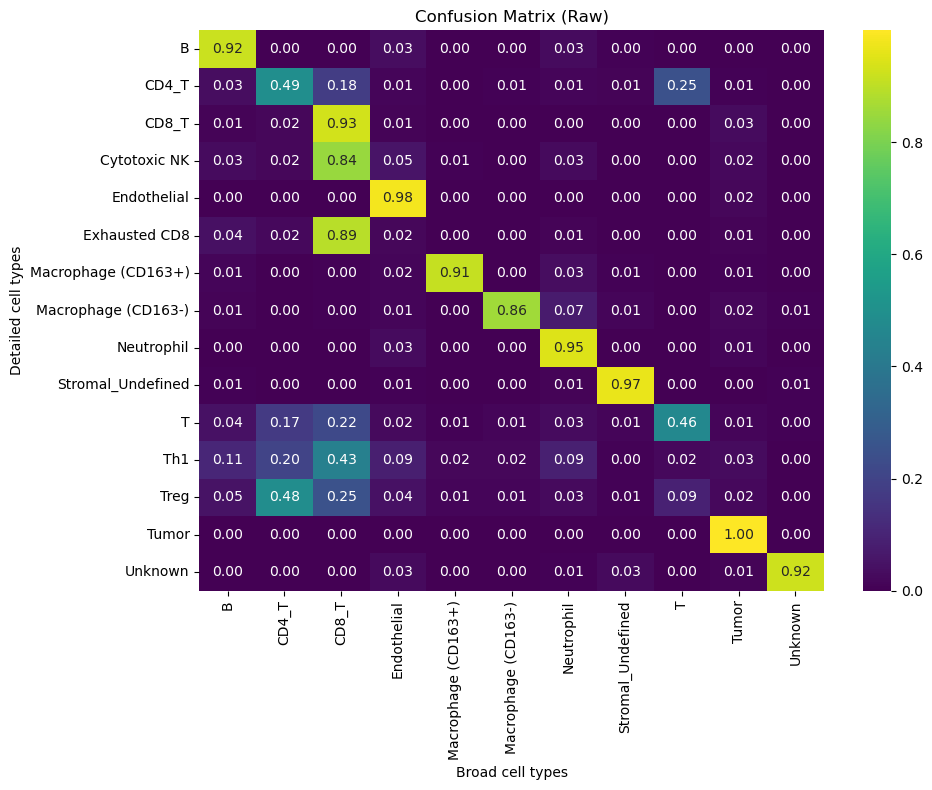


Processing: cervical_10103_raw_arcsinh
Unknown (Broad): 0.3%, Unknown (Detailed): 0.3%


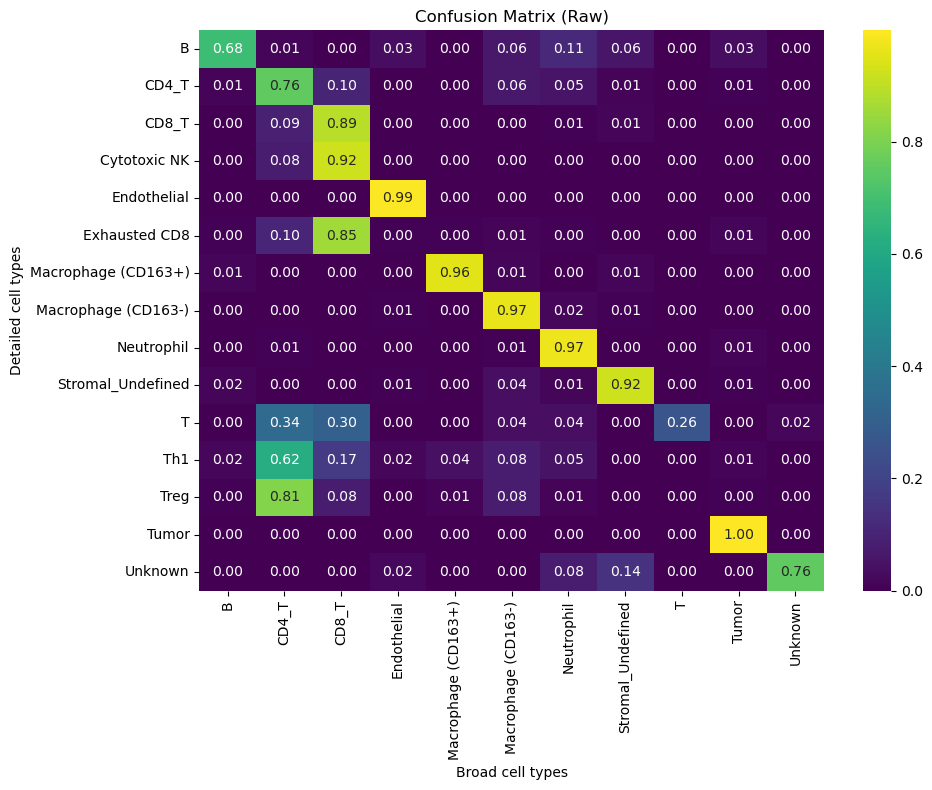


Processing: cervical_10285_raw_arcsinh
Unknown (Broad): 0.5%, Unknown (Detailed): 0.3%


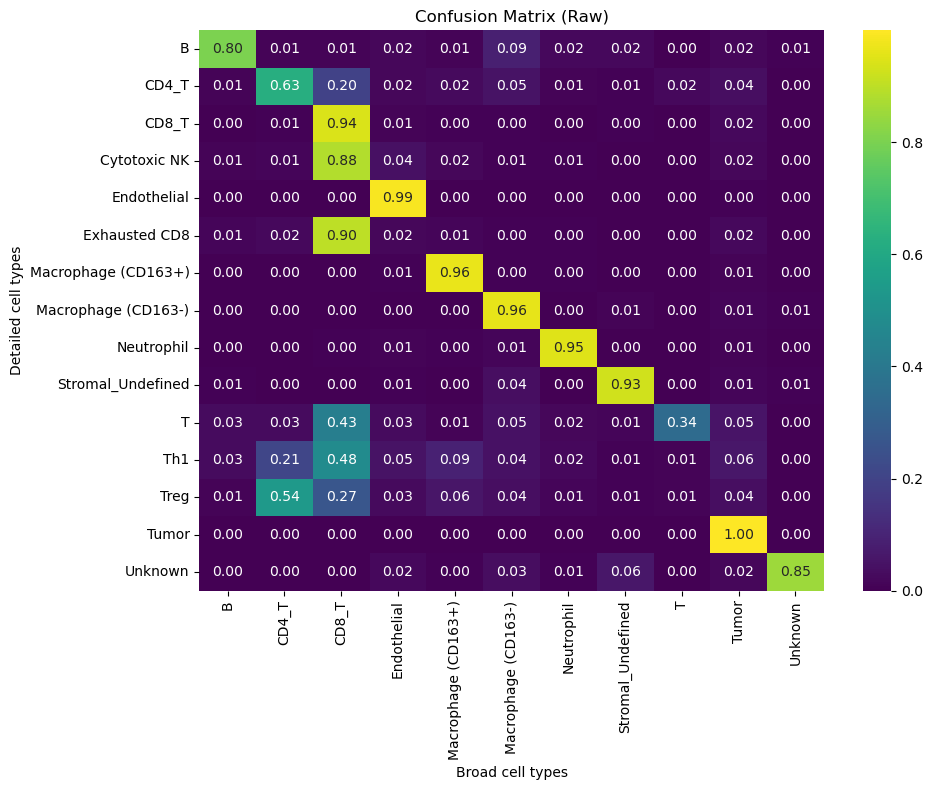


Processing: cervical_07291_raw_arcsinh
Unknown (Broad): 0.2%, Unknown (Detailed): 0.2%


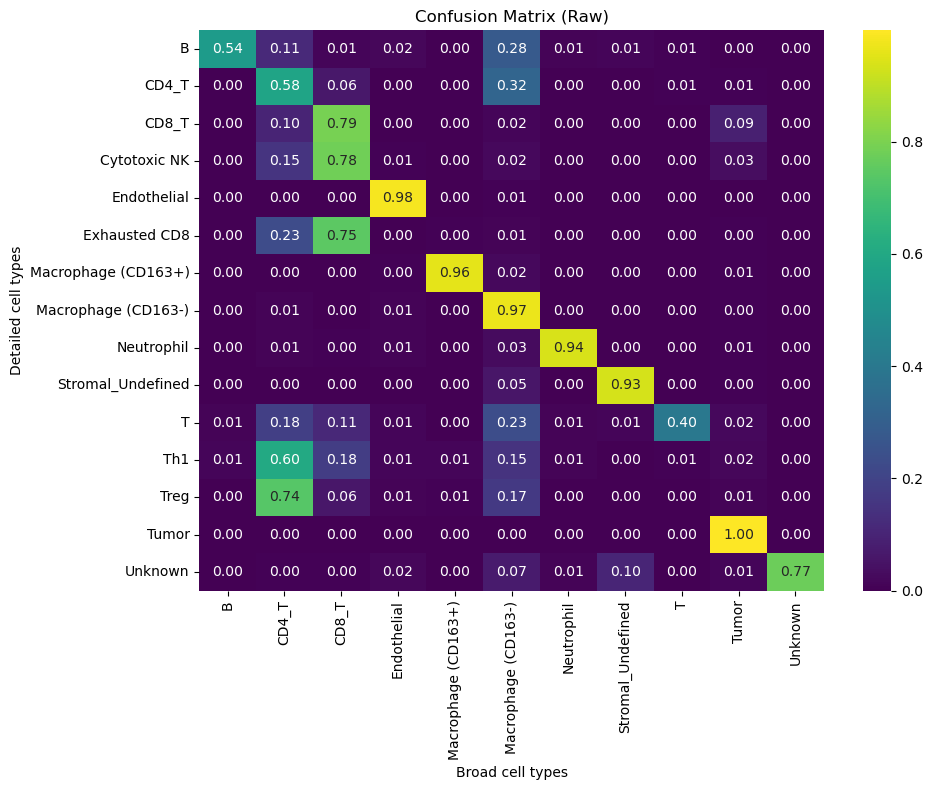


Processing: cervical_39367_raw_arcsinh
Unknown (Broad): 0.3%, Unknown (Detailed): 0.2%


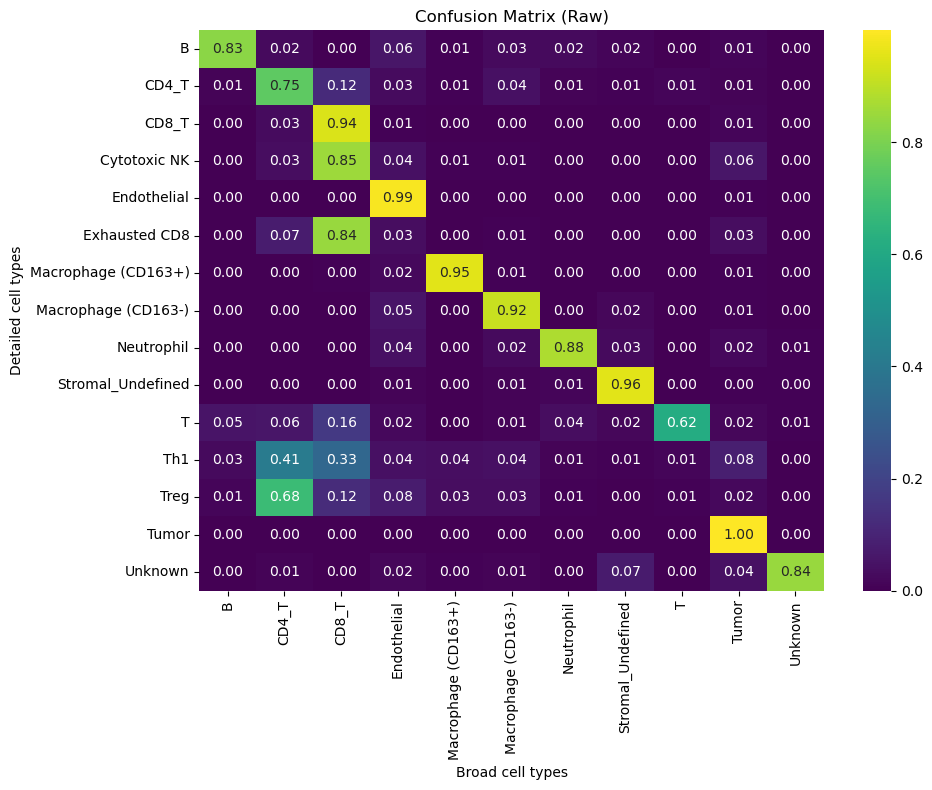


Processing: cervical_00438_raw_arcsinh
Unknown (Broad): 0.4%, Unknown (Detailed): 0.3%


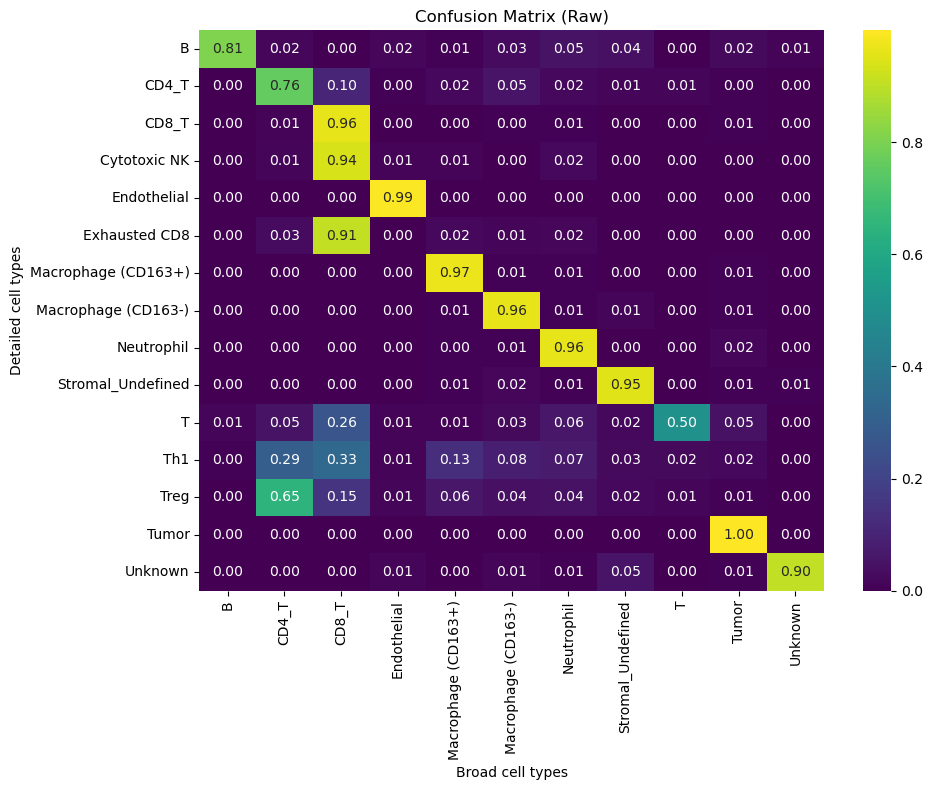


Processing: cervical_08153_raw_arcsinh
Unknown (Broad): 0.8%, Unknown (Detailed): 0.9%


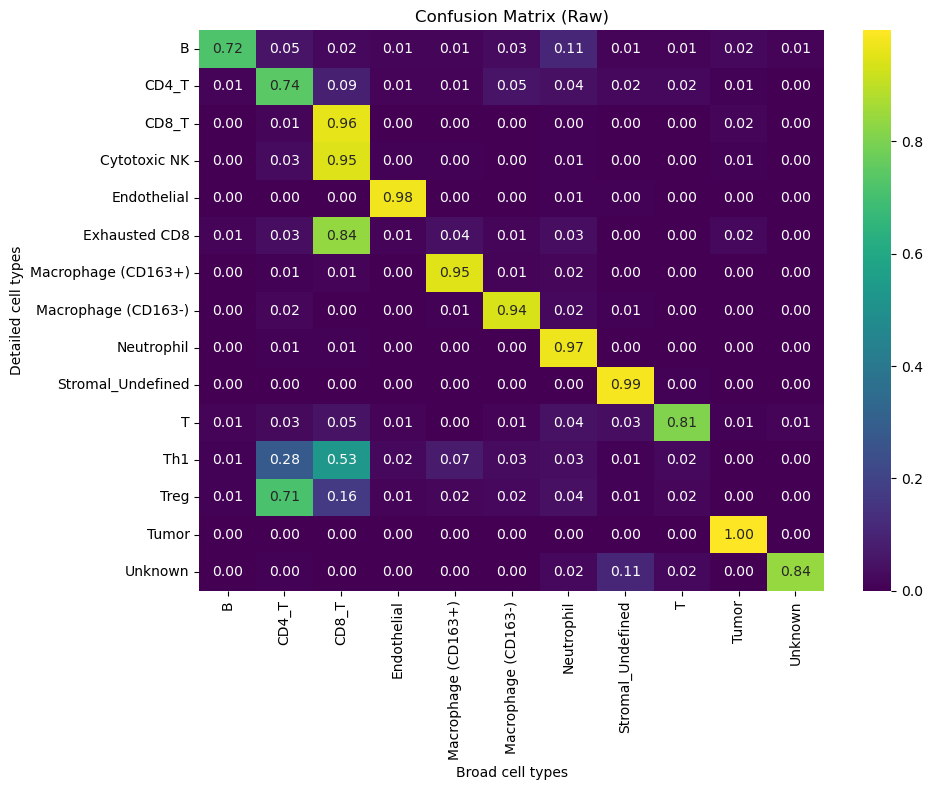


Processing: cervical_07611_raw_arcsinh
Missing file for cervical_07611_raw_arcsinh, skipping.


In [4]:
# Loop through subdirs
for subdir in os.listdir(broad_results_dir):
    if not subdir.startswith("cervical") or not os.path.isdir(os.path.join(broad_results_dir, subdir)):
        continue

    print(f"\nProcessing: {subdir}")

    # File paths
    filename = f"{subdir}_high_anchor_default_high_iter_default_final_cell_type_assignment.csv"
    broad_path = os.path.join(broad_results_dir, subdir, filename)
    detailed_path = os.path.join(detailed_results_dir, subdir, filename)

    if not (os.path.isfile(broad_path) and os.path.isfile(detailed_path)):
        print(f"Missing file for {subdir}, skipping.")
        continue

    # Read data
    broad_df = pd.read_csv(broad_path)
    detailed_df = pd.read_csv(detailed_path)

    if "Final cell type" not in broad_df.columns or "Final cell type" not in detailed_df.columns:
        print(f"'Final cell type' column missing in {subdir}, skipping.")
        continue

    broad = broad_df["Final cell type"]
    detailed = detailed_df["Final cell type"]

    # Calculate % unknown
    pct_unknown_broad = (broad == "Unknown").mean() * 100
    pct_unknown_detailed = (detailed == "Unknown").mean() * 100
    print(f"Unknown (Broad): {pct_unknown_broad:.1f}%, Unknown (Detailed): {pct_unknown_detailed:.1f}%")

    # Plot original final cell type confusion matrix
    plot_confusion_matrix(
        detailed,
        broad,
        xlabel="Broad cell types",
        ylabel="Detailed cell types",
        title_suffix="(Raw)"
    )
